<a href="https://colab.research.google.com/github/HieuStudyingCS/Learning-AI-Journey/blob/main/Gradient_descent_vs_Momentum_GD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
from numpy import linalg
import math
import matplotlib.pyplot as plt
import pandas as pd
import random
import time

## Collect Data
In this section, we will test performance between two optimization algorithms Gradient Descent and Momentum-based Gradient Descent

In [3]:
# Collect data
np.random.seed(42)

In [4]:
true_weight = 4.5
true_bias = 2.0
nb_samples = 1000
nb_features = 1

In [5]:
X = 2 * np.random.rand(nb_samples, nb_features)
X

array([[0.74908024],
       [1.90142861],
       [1.46398788],
       [1.19731697],
       [0.31203728],
       [0.31198904],
       [0.11616722],
       [1.73235229],
       [1.20223002],
       [1.41614516],
       [0.04116899],
       [1.9398197 ],
       [1.66488528],
       [0.42467822],
       [0.36364993],
       [0.36680902],
       [0.60848449],
       [1.04951286],
       [0.86389004],
       [0.58245828],
       [1.22370579],
       [0.27898772],
       [0.5842893 ],
       [0.73272369],
       [0.91213997],
       [1.57035192],
       [0.39934756],
       [1.02846888],
       [1.18482914],
       [0.09290083],
       [1.2150897 ],
       [0.34104825],
       [0.13010319],
       [1.89777107],
       [1.93126407],
       [1.6167947 ],
       [0.60922754],
       [0.19534423],
       [1.36846605],
       [0.88030499],
       [0.24407647],
       [0.99035382],
       [0.06877704],
       [1.8186408 ],
       [0.51755996],
       [1.32504457],
       [0.62342215],
       [1.040

In [6]:
y = true_weight * X + true_bias + np.random.randn(1000, 1) #  y = 4.5 * X + 2 + noise
y

array([[5.54856207e+00],
       [9.22108440e+00],
       [8.96814333e+00],
       [7.99851210e+00],
       [3.96395821e+00],
       [4.48473141e+00],
       [3.35667466e+00],
       [1.02547654e+01],
       [7.33986939e+00],
       [6.71169227e+00],
       [2.61487867e+00],
       [1.09368764e+01],
       [9.76356260e+00],
       [2.63430342e+00],
       [2.55536816e+00],
       [4.70379344e+00],
       [4.69862503e+00],
       [7.40430858e+00],
       [5.91582354e+00],
       [4.65081840e+00],
       [8.44495986e+00],
       [2.73940002e+00],
       [4.72542261e+00],
       [4.83498130e+00],
       [5.67013363e+00],
       [8.75741153e+00],
       [4.01919781e+00],
       [6.14936132e+00],
       [8.58748725e+00],
       [1.52344641e+00],
       [7.28103202e+00],
       [3.09498605e+00],
       [4.03244222e+00],
       [1.07365246e+01],
       [1.17225328e+01],
       [7.79001576e+00],
       [5.00857419e+00],
       [3.76867982e+00],
       [8.24038123e+00],
       [7.02685282e+00],


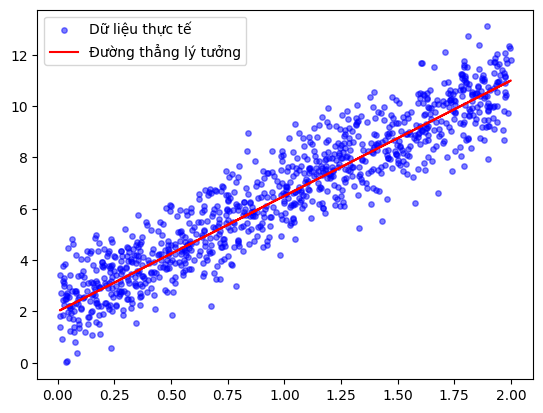

In [7]:
plt.scatter(X, y, color='blue', alpha=0.5, s=15, label='Dữ liệu thực tế')
plt.plot(X, true_weight * X + true_bias, color='red', label='Đường thẳng lý tưởng')
plt.legend()
plt.show()

## Gradient Descent

In [8]:
def graient(w_0, w_1, x):
  return w_0

In [9]:
def loss_function(y_pred, y):
  return np.mean((y_pred  - y)**2)

In [17]:
def gradient_descent(X, y, eta=0.01):
  w = np.zeros((X.shape[1], 1))
  loss_history = []
  N = X.shape[0]
  w_0 = 0
  nb_iterations = 0

  for _ in range(100000):
    nb_iterations += 1
    y_pred = np.dot(X, w) + w_0
    loss = loss_function(y_pred, y)
    loss_history.append(loss)
    dw = (2 / N) * np.dot(X.T, (y_pred - y))
    db = (2 / N) * np.sum(y_pred - y)

    if(loss < 1e-3): break
    if len(loss_history) > 1 and abs(loss_history[-1] - loss_history[-2]) < 1e-6: break

    w -= eta*dw
    w_0 -= eta*db
  return w, w_0, loss_history, nb_iterations

## Estimate time and the number of iterations for GD Algo

In [18]:
def momentum_gradient_descent(X, y, gamma=0.9, eta=0.01):
    w = np.zeros((X.shape[1], 1))
    loss_history = []
    N = X.shape[0]
    w_0 = 0
    nb_iterations = 0

    v_w = np.zeros((X.shape[1], 1))
    v_w0 = 0

    for _ in range(100000):
        nb_iterations += 1

        y_pred = np.dot(X, w) + w_0
        loss = loss_function(y_pred, y)
        loss_history.append(loss)

        dw = (2 / N) * np.dot(X.T, (y_pred - y))
        db = (2 / N) * np.sum(y_pred - y)

        if (loss < 1e-3):
            break
        if len(loss_history) > 1 and abs(loss_history[-1] - loss_history[-2]) < 1e-6: break

        v_w = gamma * v_w + eta * dw
        v_w0 = gamma * v_w0 + eta * db

        w -= v_w
        w_0 -= v_w0

    return w, w_0, loss_history, nb_iterations

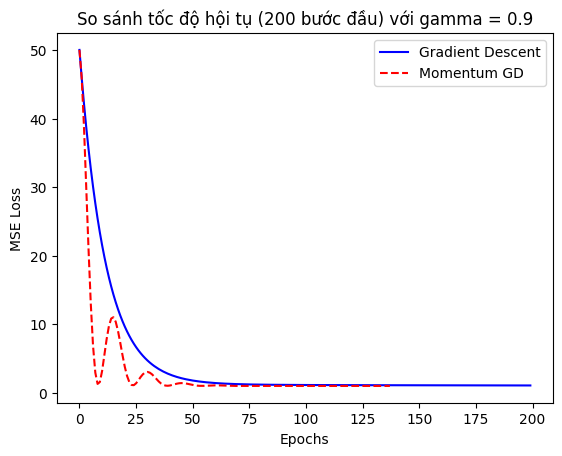

Trọng số thực tế: w=4.5, b=2.0
GD tìm được: w=4.402, b=2.199
Momentum tìm được: w=4.426, b=2.176
Số lượng bước GD: 1152
Số lượng bước Momentum GD: 138


In [26]:
# Gamma = 0.9
w_gd, b_gd, loss_gd, nb_iterations_GD = gradient_descent(X, y, eta=0.01)
w_mom, b_mom, loss_mom, nb_iterations_MGD = momentum_gradient_descent(X, y, eta=0.01, gamma=0.9)

plt.plot(loss_gd[:200], label='Gradient Descent', color='blue')
plt.plot(loss_mom[:200], label='Momentum GD', color='red', linestyle='--')

plt.title(f'So sánh tốc độ hội tụ (200 bước đầu) với gamma = 0.9')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

print(f"Trọng số thực tế: w={4.5}, b={2.0}")
print(f"GD tìm được: w={w_gd[0][0]:.3f}, b={b_gd:.3f}")
print(f"Momentum tìm được: w={w_mom[0][0]:.3f}, b={b_mom:.3f}")
print(f'Số lượng bước GD: {nb_iterations_GD}')
print(f'Số lượng bước Momentum GD: {nb_iterations_MGD}')

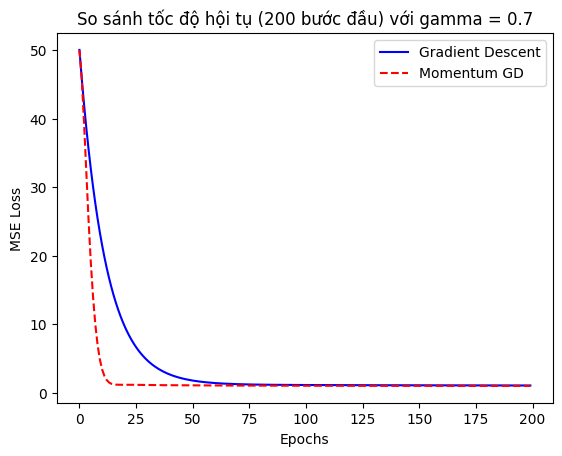

Trọng số thực tế: w=4.5, b=2.0
GD tìm được: w=4.402, b=2.199
Momentum tìm được: w=4.412, b=2.187
Số lượng bước GD: 1152
Số lượng bước Momentum GD: 396


In [27]:
# Gamma = 0.7
w_gd, b_gd, loss_gd, nb_iterations_GD = gradient_descent(X, y, eta=0.01)
w_mom, b_mom, loss_mom, nb_iterations_MGD = momentum_gradient_descent(X, y, eta=0.01, gamma=0.7)

plt.plot(loss_gd[:200], label='Gradient Descent', color='blue')
plt.plot(loss_mom[:200], label='Momentum GD', color='red', linestyle='--')

plt.title(f'So sánh tốc độ hội tụ (200 bước đầu) với gamma = 0.7')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

print(f"Trọng số thực tế: w={4.5}, b={2.0}")
print(f"GD tìm được: w={w_gd[0][0]:.3f}, b={b_gd:.3f}")
print(f"Momentum tìm được: w={w_mom[0][0]:.3f}, b={b_mom:.3f}")
print(f'Số lượng bước GD: {nb_iterations_GD}')
print(f'Số lượng bước Momentum GD: {nb_iterations_MGD}')

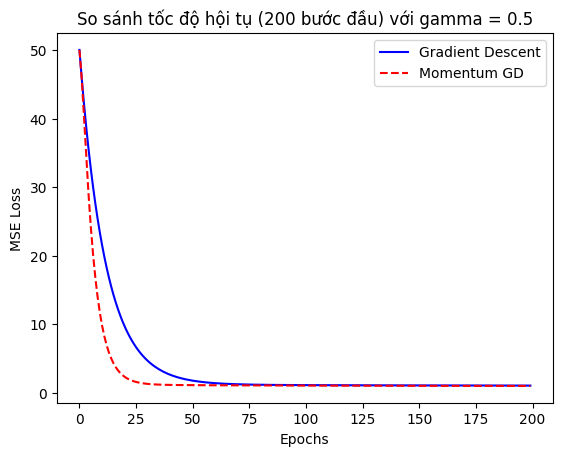

Trọng số thực tế: w=4.5, b=2.0
GD tìm được: w=4.402, b=2.199
Momentum tìm được: w=4.408, b=2.191
Số lượng bước GD: 1152
Số lượng bước Momentum GD: 628


In [29]:
# Gamma = 0.5
w_gd, b_gd, loss_gd, nb_iterations_GD = gradient_descent(X, y, eta=0.01)
w_mom, b_mom, loss_mom, nb_iterations_MGD = momentum_gradient_descent(X, y, eta=0.01, gamma=0.5)

plt.plot(loss_gd[:200], label='Gradient Descent', color='blue')
plt.plot(loss_mom[:200], label='Momentum GD', color='red', linestyle='--')

plt.title(f'So sánh tốc độ hội tụ (200 bước đầu) với gamma = 0.5')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

print(f"Trọng số thực tế: w={4.5}, b={2.0}")
print(f"GD tìm được: w={w_gd[0][0]:.3f}, b={b_gd:.3f}")
print(f"Momentum tìm được: w={w_mom[0][0]:.3f}, b={b_mom:.3f}")
print(f'Số lượng bước GD: {nb_iterations_GD}')
print(f'Số lượng bước Momentum GD: {nb_iterations_MGD}')